In [2]:
import sys
import os
from pathlib import Path
# Go up until you find the project root
while not (Path.cwd() / ".gitignore").exists() and Path.cwd() != Path("/"):
    os.chdir("..")


In [3]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import matplotlib.pyplot as plt
import numpy as np
from src.utils import split_pa_train_test_spatially, split_pa_train_test_kmeans
from src.pa_split import partition_sweep

In [4]:
def naturalearth_country(country_name="France", scale="110m", metropolitan_only=True):
    world = gpd.read_file(
        f"https://naturalearth.s3.amazonaws.com/{scale}_cultural/ne_{scale}_admin_0_countries.zip"
    )
    country = world[world["NAME"] == country_name]
    if country.empty:
        raise ValueError(f"'{country_name}' not found in Natural Earth NAME field.")

    geom = country.geometry.iloc[0]

    # Natural Earth "France" includes overseas parts; isolate mainland
    if metropolitan_only and country_name == "France":
        if geom.geom_type == "MultiPolygon":
            parts = gpd.GeoDataFrame(geometry=list(geom.geoms), crs=country.crs)
        else:
            parts = gpd.GeoDataFrame(geometry=[geom], crs=country.crs)

        # Keep the polygon whose centroid falls in a mainland-France bbox
        cent = parts.geometry.centroid
        parts = parts[cent.x.between(-6, 10) & cent.y.between(41, 52)]

        if parts.empty:
            raise ValueError("Could not isolate metropolitan France from geometry parts.")

        geom = parts.unary_union

    return gpd.GeoDataFrame({"NAME": [country_name]}, geometry=[geom], crs=country.crs)

In [5]:

# --- build France border from Natural Earth ---
gdf_map = naturalearth_country("France", scale="110m", metropolitan_only=True)

# read data\raw\NCEAS\Records\train_po\AWTtrain_po.csv with region variable
df_po = gpd.read_file(f'data/processed/geoplant/geoplant_po_france_withcovs.csv')


# data\raw\NCEAS\Records\test_pa\AWTtest_pa_bird.csv
# df_pa = gpd.read_file(f'data/raw/NCEAS/Records/test_pa/{region.upper()}test_pa{group_}{group}.csv')
df_pa = gpd.read_file(f'data/processed/geoplant/geoplant_pa_france_withcovs.csv')
# df_env = pd.read_csv(f'data/raw/NCEAS/Records/test_env/{region.upper()}test_env{group_}{group}.csv')
df_pa[['x','y']] = df_pa[['lon','lat']].astype('float')
df_po[['x','y']] = df_po[['lon','lat']].astype('float')
# df_pa_tr, df_pa_te, foo1, foo2 = split_pa_train_test_spatially(df_pa, df_pa)

gdf_points_po = gpd.GeoDataFrame(
    df_po,
    geometry=gpd.points_from_xy(df_po.x, df_po.y),
    crs=str(gdf_map.crs)  # Set CRS (important!)
    )

gdf_points_pa = gpd.GeoDataFrame(
    df_pa,
    geometry=gpd.points_from_xy(df_pa.x, df_pa.y),
    crs=str(gdf_map.crs)  # Set CRS (important!)
    )


# fig, ax1, ax2 = plt.subplots(figsize=(5, 5), nrows=1, ncols=2)
# fig, (ax1, ax2) = plt.subplots(figsize=(10, 5), nrows=1, ncols=2)
# gdf_map.plot(ax=ax1, color="whitesmoke", edgecolor="gray", linewidth=0.5)
# gdf_points_pa.plot(ax=ax1, color="green", markersize=2, label="Presence-Absence", alpha=0.9)
# gdf_map.plot(ax=ax2, color="whitesmoke", edgecolor="gray", linewidth=0.5)
# gdf_points_po.plot(ax=ax2, color="red", markersize=2, label="Presence-Only", alpha=0.9)


/var/folders/5z/fxhhptss4lvf4sbcrvw0bg4wqxvp22/T/ipykernel_11367/2444038406.py:19: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cent = parts.geometry.centroid
/var/folders/5z/fxhhptss4lvf4sbcrvw0bg4wqxvp22/T/ipykernel_11367/2444038406.py:25: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = parts.unary_union


In [6]:
# read results output/integration_analysis/summary.csv
df_results = pd.read_csv('output/integration_geoplant/partition_results.csv')



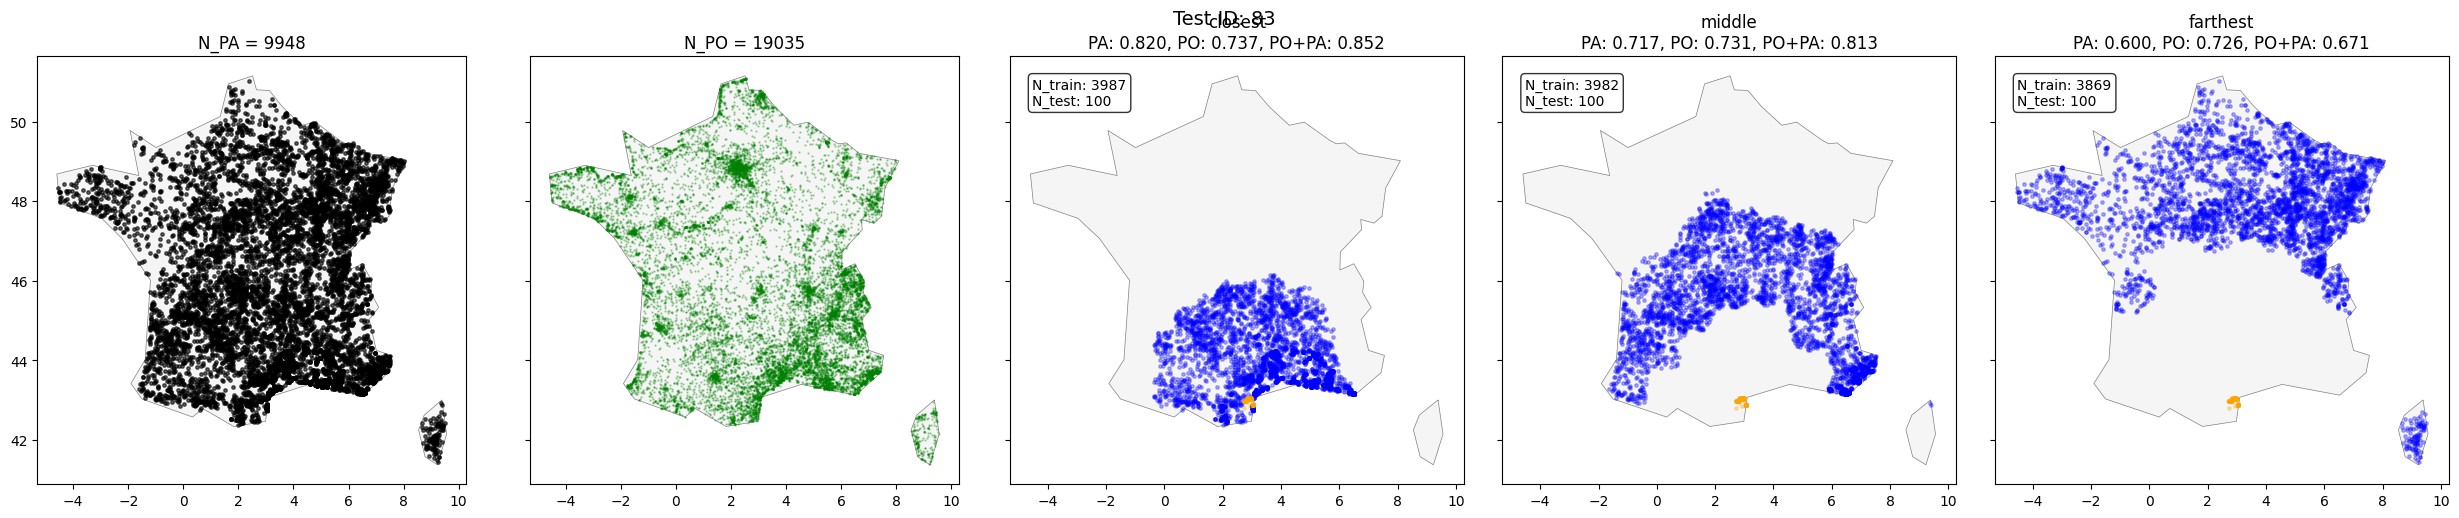

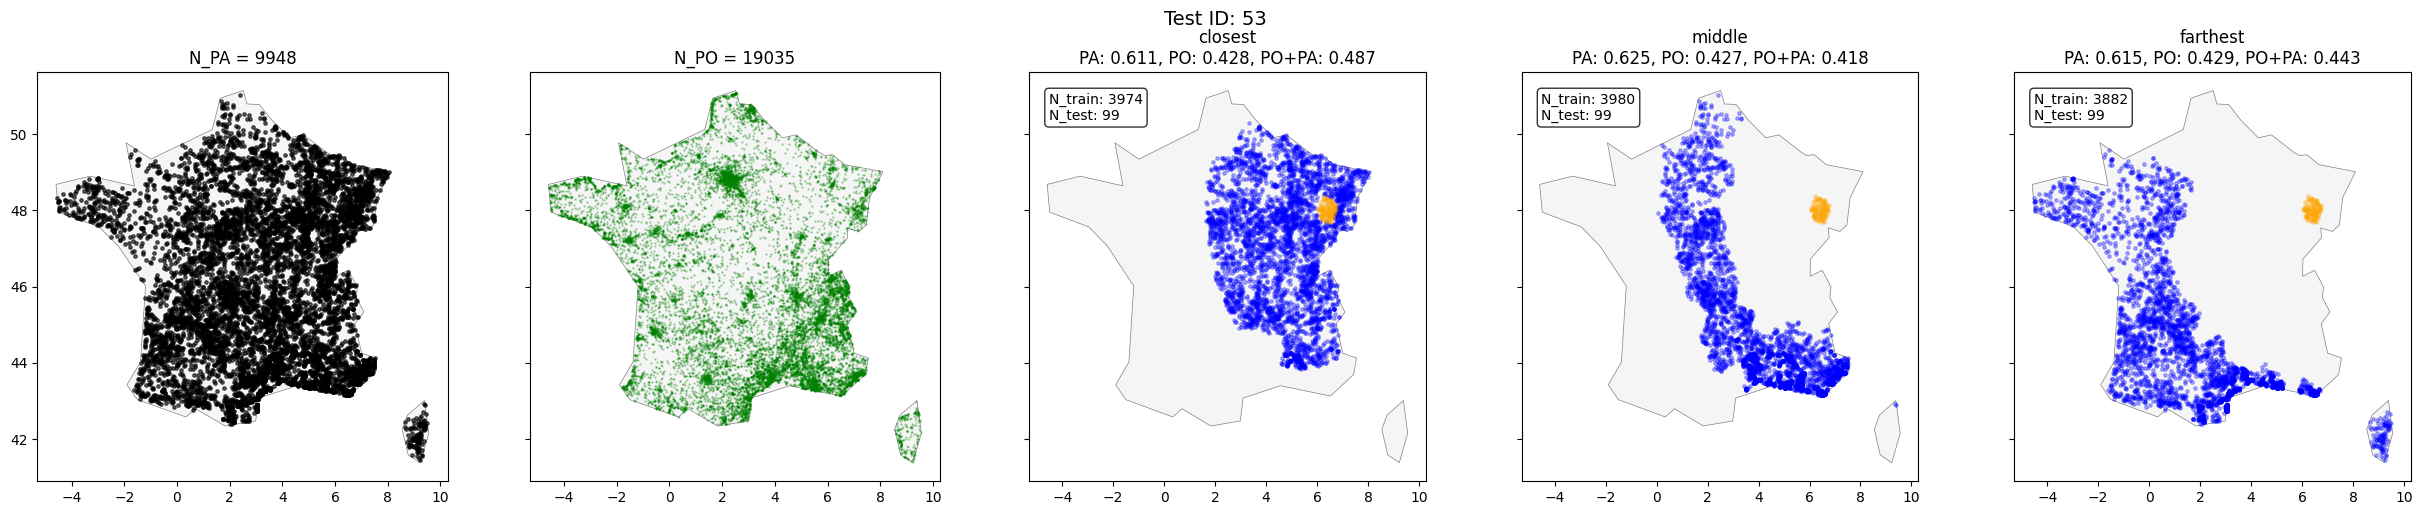

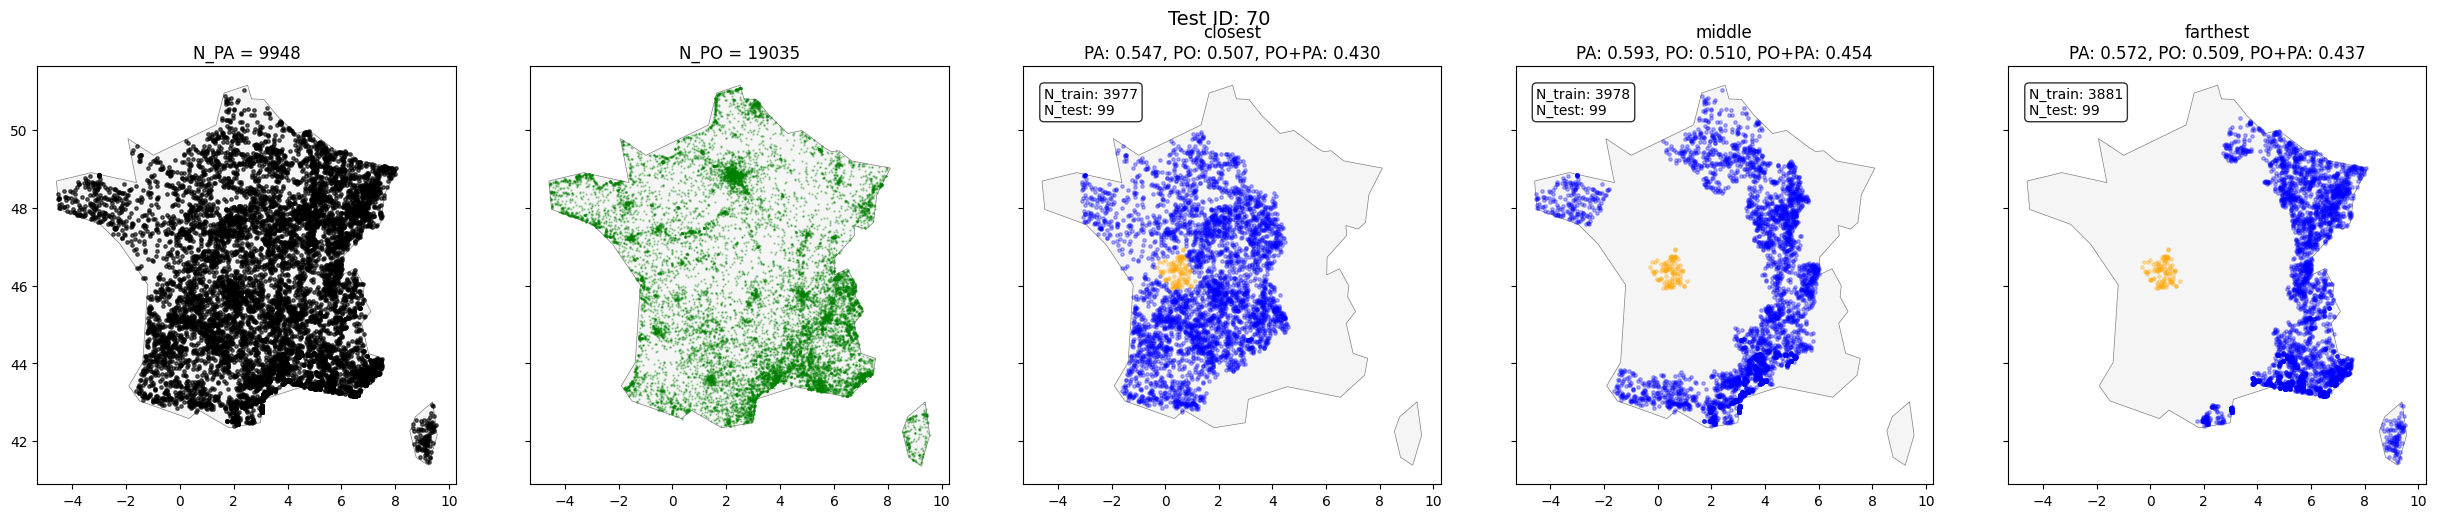

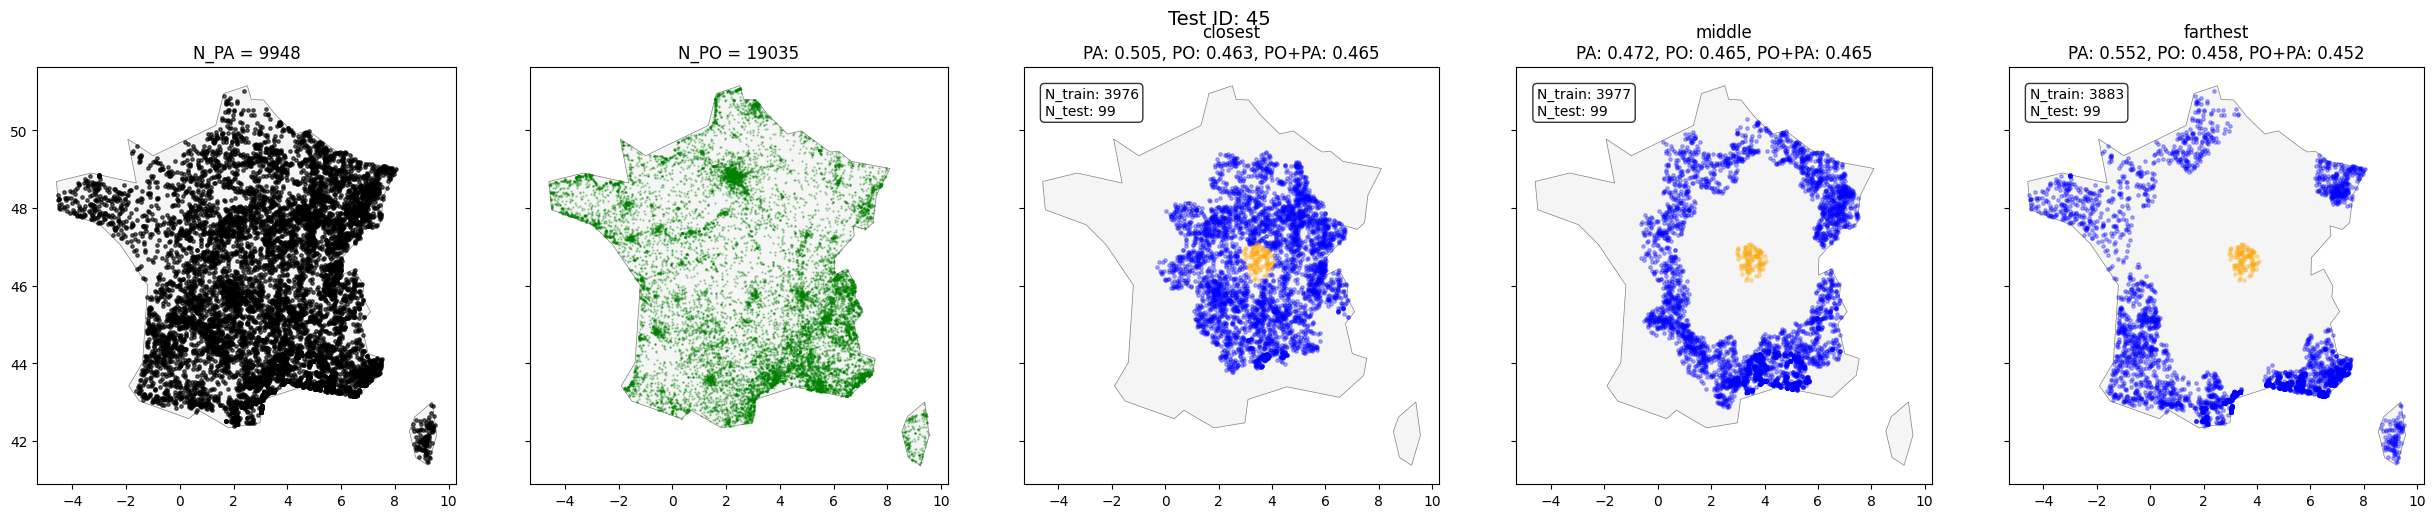

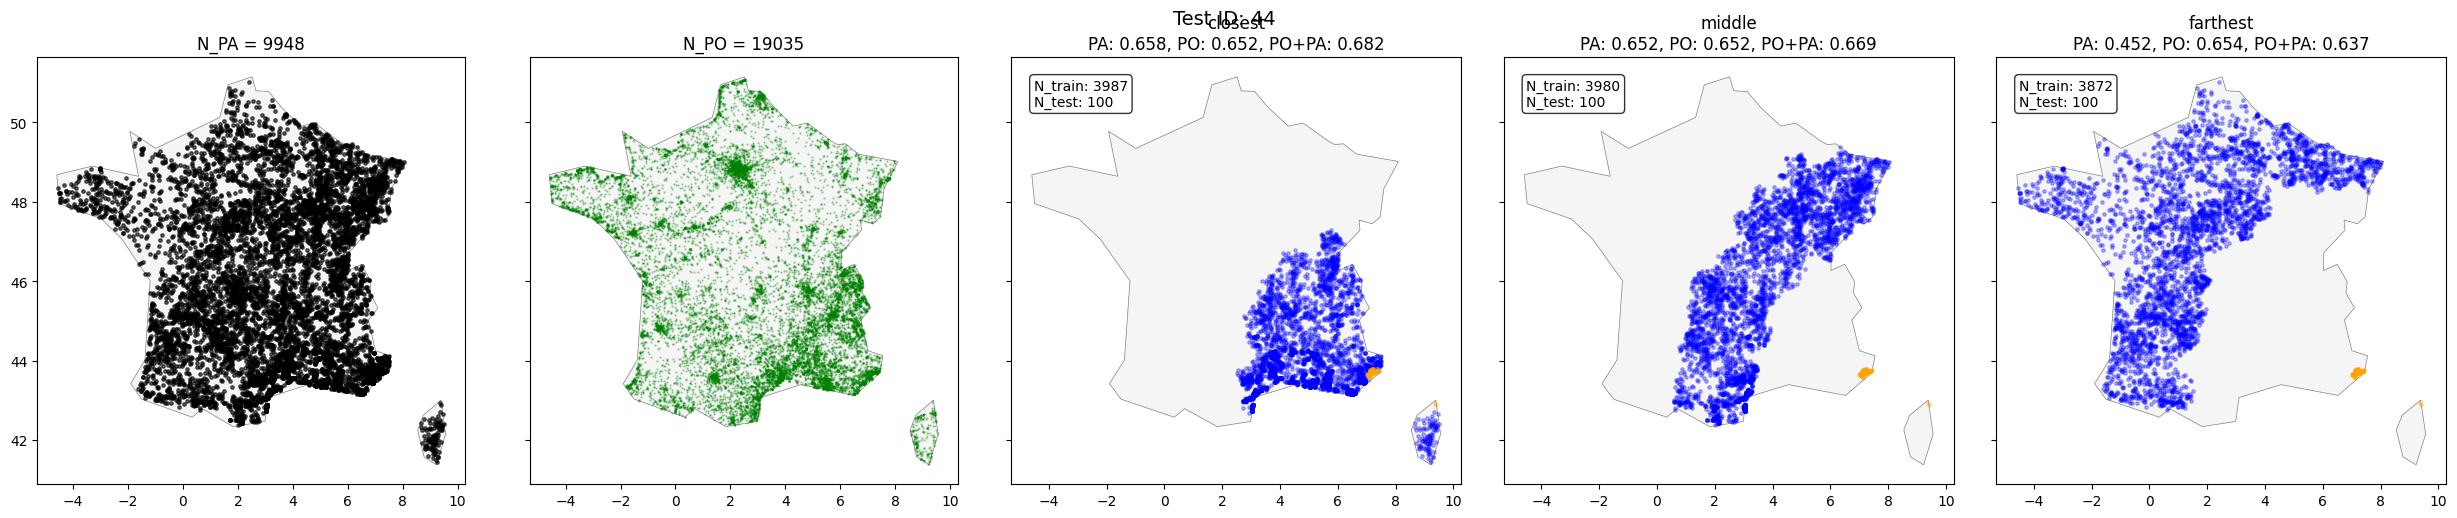

In [7]:
import ast
import matplotlib.pyplot as plt
import geopandas as gpd

unique_test_ids = df_results['test_id'].unique()
split_types = ['closest', 'middle', 'farthest']

for test_id in unique_test_ids:
    ncols = len(split_types) + 2  # 1 reference plot for po and 1 for pa + split types
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5), sharex=True, sharey=True)

    # ---------- Reference plot (all points) ----------
    ax_ref = axes[0]

    gdf_map.plot(ax=ax_ref, color="whitesmoke", edgecolor="gray", linewidth=0.5)

    gdf_all = gpd.GeoDataFrame(
        df_pa,
        geometry=gpd.points_from_xy(df_pa.x, df_pa.y),
        crs=str(gdf_map.crs),
    )
    gdf_all.plot(ax=ax_ref, color="black", markersize=6, alpha=0.6)

    ax_ref.set_title(f'N_PA = {len(df_pa)}')

    # for po the same
    ax_ref_po = axes[1]
    gdf_map.plot(ax=ax_ref_po, color="whitesmoke", edgecolor="gray", linewidth=0.5)
    gdf_all_po = gpd.GeoDataFrame(
        df_po,
        geometry=gpd.points_from_xy(df_po.x, df_po.y),
        crs=str(gdf_map.crs),
    )
    gdf_all_po.plot(ax=ax_ref_po, color="green", markersize=.5
    , alpha=0.3)
    size_po = len(df_po)
    ax_ref_po.set_title(f'N_PO = {size_po}')

    # ---------- Split-specific plots ----------
    for i, split_type in enumerate(split_types, start=2):
        ax = axes[i]

        subset = df_results[
            (df_results['test_id'] == test_id)
            & (df_results['split_type'] == split_type)
        ]

        if subset.empty:
            ax.set_title(f"{split_type} (no data)")
            continue

        # safer than eval
        train_indexes = ast.literal_eval(subset['train_indexes'].values[0])
        test_indexes = ast.literal_eval(subset['test_indexes'].values[0])

        df_pa_tr = df_pa.iloc[train_indexes]
        df_pa_te = df_pa.iloc[test_indexes]

        gdf_pa_tr = gpd.GeoDataFrame(
            df_pa_tr,
            geometry=gpd.points_from_xy(df_pa_tr.x, df_pa_tr.y),
            crs=str(gdf_map.crs),
        )
        gdf_pa_te = gpd.GeoDataFrame(
            df_pa_te,
            geometry=gpd.points_from_xy(df_pa_te.x, df_pa_te.y),
            crs=str(gdf_map.crs),
        )

        gdf_map.plot(ax=ax, color="whitesmoke", edgecolor="gray", linewidth=0.5)
        gdf_pa_tr.plot(ax=ax, color="blue", markersize=6, alpha=0.3)
        gdf_pa_te.plot(ax=ax, color="orange", markersize=6, alpha=0.3)

        auc_pa = subset['AUC_PA_only'].values[0]
        auc_po = subset['AUC_PO_only'].values[0]
        auc_popa = subset['AUC_PO_plus_PA'].values[0]
    
        # add all info in the title of auc and split type
        size_split_tr, size_split_te = len(df_pa_tr), len(df_pa_te)
        ax.set_title(
            f"{split_type}\nPA: {auc_pa:.3f}, PO: {auc_po:.3f}, PO+PA: {auc_popa:.3f}"
        )

        # add a box with train and test sizes
        ax.text(
            0.05,
            0.95,
            f"N_train: {size_split_tr}\nN_test: {size_split_te}",
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

    fig.suptitle(
        f"Test ID: {test_id}",
        fontsize=14,
    )

    plt.tight_layout()
    plt.show()

